In [2]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt



# Problem 1

$$\min f(x) = e^{x_1 - 1} + e^{-x_1 + 1} + e^{x_2-2} + e^{-x_2 +2 } + e^{-x_3 + 3} + (x_1 - 2x_2 +5x_3)^4$$

$$\nabla f(x) = \begin{pmatrix} 
e^{x_1 - 1} - e^{-x_1 + 1} + 4(x_1 - 2x_2 +5x_3)^3 \\
e^{x_2 - 2} - e^{-x_2 + 2} - 9(x_1 - 2x_2 +5x_3)^3 \\
-e^{x_3 + 3}  + 20(x_1 - 2x_2 +5x_3)^3 \\
\end{pmatrix}
$$

In [3]:
# Write a code in CVX to find the global minimum x*

x1 = cp.Variable()
x2 = cp.Variable()
x3 = cp.Variable()

objective = cp.Minimize(
    cp.exp(x1-1) + cp.exp(-x1+1) +
    cp.exp(x2-2) + cp.exp(-x2+2) +
    cp.exp(x3-3) + cp.exp(-x3+3) +
    cp.power((x1 - 2*x2 + 5*x3), 4)
)

problem = cp.Problem(objective)
problem.solve()

x1_cp = x1.value
x2_cp = x2.value
x3_cp = x3.value

print(f"CVXPY Solution: x1 = {x1_cp}, x2 = {x2_cp}, x3 = {x3_cp}")

CVXPY Solution: x1 = 0.4573801355825401, x2 = 2.976508302346172, x3 = 1.2307154858979108


In [4]:
# Then, write a code that implements the Gradient method with your choice of the backtracking parameters. 

x1 = 1
x2 = 1
x3 = 1

arr_g = []
arr_g.append([x1, x2, x3])


def f(x):
    x1, x2, x3 = x
    return (np.exp(x1-1) + np.exp(-x1+1) + np.exp(x2-2) + np.exp(-x2+2) + np.exp(x3-3) + np.exp(-x3+3) + (x1 - 2*x2 + 5*x3)**4)


def calc_gradient(x):
    x1, x2, x3 = x

    dx1 = np.exp(x1-1) - np.exp(-x1+1) + 4 * (x1 - 2*x2 + 5*x3)**3 * 1
    dx2 = np.exp(x2-2) - np.exp(-x2+2) + 4 * (x1 - 2*x2 + 5*x3)**3 * (-2)
    dx3 = np.exp(x3-3) - np.exp(-x3+3) + 4 * (x1 - 2*x2 + 5*x3)**3 * (5)
    return np.array([dx1, dx2, dx3])


def step_size():
    # backtracking line search 
    alpha = 0.05  # Step size reduction factor
    beta = 0.1  # Inital t

    while f(arr_g[-1] - beta * calc_gradient(arr_g[-1])) >= f(arr_g[-1]):
        beta *= alpha

    return beta


for i in range(51):
    gradient = calc_gradient(arr_g[-1])
    t = step_size()
    x_new = arr_g[-1] - t * gradient
    arr_g.append(x_new)

xstar = arr_g[-1]
print(f"Gradient Descent Solution: x1 = {xstar[0]}, x2 = {xstar[1]}, x3 = {xstar[2]}")

Gradient Descent Solution: x1 = 0.4566138962977194, x2 = 2.972826937170818, x3 = 1.2294275351541832


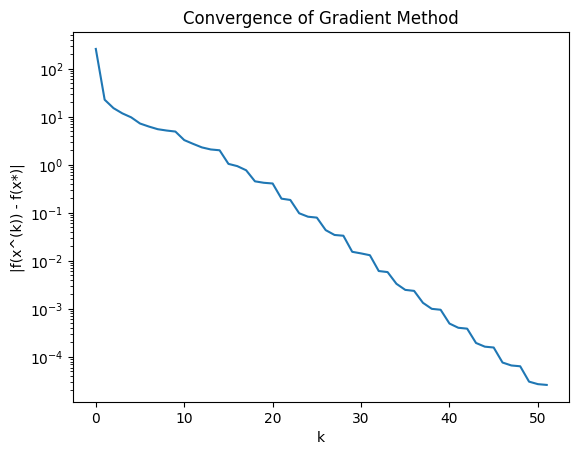

In [5]:
# Draw |f(x(k)) − f(x∗)| verses k for k = 0, 1, 2, . . . , 50 on alog-linear plot. 
# Show the trajectory of the points x(0), x(1), ..., x(50) in the 3-dimensional (x1, x2, x3) plane.

f_vals = np.array([f(x) for x in arr_g])

x_star = np.array([x1_cp, x2_cp, x3_cp])
f_star = f(x_star)

errors = np.abs(f_vals - f_star)
k = np.arange(len(arr_g))

plt.semilogy(k, errors)

plt.xlabel("k")
plt.ylabel("|f(x^(k)) - f(x*)|")
plt.title("Convergence of Gradient Method")

plt.show()

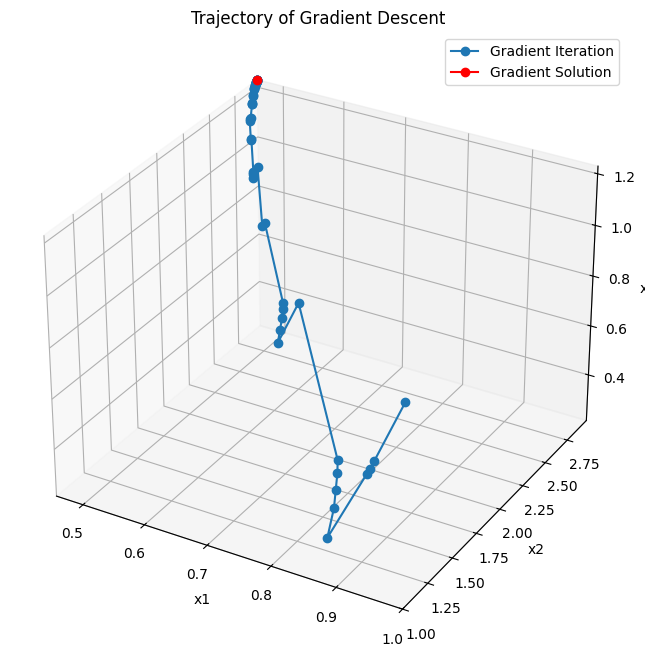

In [6]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(111, projection="3d")

arr_g = np.array(arr_g)

ax.plot(arr_g[:,0], arr_g[:,1], arr_g[:,2], marker="o", label = "Gradient Iteration")

ax.plot(*xstar, marker="o", color="red", label = "Gradient Solution")

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("Trajectory of Gradient Descent")

ax.set_xlim(min(arr_g[:,0]), max(arr_g[:,0]) )
ax.set_ylim(min(arr_g[:,1]), max(arr_g[:,1]) )
ax.set_zlim(min(arr_g[:,2]), max(arr_g[:,2]) )
ax.legend()

plt.show()

\newpage

# Problem 2
Redo the previous problem with Newton’s method.


$$\min f(x) = e^{x_1 - 1} + e^{-x_1 + 1} + e^{x_2-2} + e^{-x_2 +2 } + e^{-x_3 + 3} + (x_1 - 2x_2 +5x_3)^4$$

$$\nabla f(x) = \begin{pmatrix} 
e^{x_1 - 1} - e^{-x_1 + 1} + 4(x_1 - 2x_2 +5x_3)^3 \\
e^{x_2 - 2} - e^{-x_2 + 2} - 8(x_1 - 2x_2 +5x_3)^3 \\
-e^{x_3 + 3}  + 20(x_1 - 2x_2 +5x_3)^3 \\
\end{pmatrix}
$$

$$\nabla^2 f(x) = \begin{pmatrix} 
e^{x_1 - 1} + e^{-x_1 + 1} + 12(x_1 - 2x_2 + 5x_3)^2 & -24(x_1 - 2x_2 + 5x_3)^2 & 60(x_1 - 2x_2 + 5x_3)^2\\
-24(x_1 - 2x_2 + 5x_3)^2 & e^{x_2 - 2} + e^{-x_2 +2} + 48 (x_1 - 2x_2 + 5x_3)^2 & -120(x_1 - 2x_2 + 5x_3)^2 \\
60(x_1 - 2x_2 + 5x_3)^2 & -120(x_1 - 2x_2 + 5x_3)^2 & e^{x_3 + 3} + 300(x_1 - 2x_2 + 5x_3)^2
\end{pmatrix}$$

In [38]:
x_0 = [1,1,1]
arr_n = []
arr_n.append(x_0)

# compute gradient (implemented in 1st part)

# compute hessian 
def calc_hessian(x):
    
    x1, x2, x3 = x
    
    dx1x1 = np.exp(x1 - 1) + np.exp(-x1 +1) + 12 * (x1 - 2*x2 + 5*x3)**2
    dx1x2 = -24 * (x1 - 2*x2 + 5*x3)**2
    dx1x3 = 60 * (x1 - 2*x2 + 5*x3)**2
    
    dx2x1 = dx1x2
    dx2x2 = np.exp(x2 - 2) + np.exp(-x2 + 2) + 48 * (x1 - 2*x2 + 5*x3)**2
    dx2x3 = -120 * (x1 - 2*x2 + 5*x3)**2
    
    dx3x1 = dx1x3
    dx3x2 = dx2x3
    dx3x3 = np.exp(x3 - 3) + 300 * (x1 - 2*x2 + 5*x3)**2
    
    hessian = np.array([
        [dx1x1, dx1x2, dx1x3],
        [dx2x1, dx2x2, dx2x3],
        [dx3x1, dx3x2, dx3x3]
    ])

    return hessian 

    

# compute direction 
def calc_direction(x):
    # delta = - H^-1 * g
    delta = np.linalg.solve(calc_hessian(x), -calc_gradient(x))
    return delta

# step size 
def step_size(x):
    # backtracking 
    alpha = 0.5
    beta = 0.4
    
    direction = calc_direction(x)
    tol = 1e-20
    while f(x + beta * direction) >= f(x) and beta > tol:
        beta *= alpha
    
    return beta 

for i in range(50):
    # compute step size
    curr_x = arr_n[-1]
    
    new_x = curr_x + step_size(curr_x) * calc_direction(curr_x)
    arr_n.append(new_x)

x_star = arr_n[-1]
print(f"Newton's Method Solution: x1 = {x_star[0]}, x2 = {x_star[1]}, x3 = {x_star[2]}")

Newton's Method Solution: x1 = 0.4573950392090808, x2 = 2.97649383192283, x3 = 1.2307065747966477


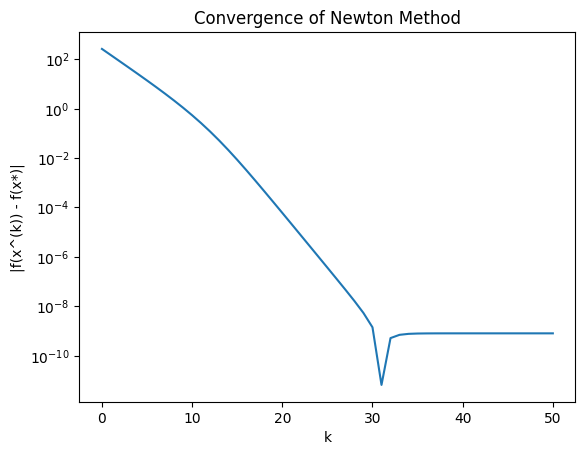

In [36]:
f_vals = np.array([f(x) for x in arr_n])

x_star = np.array([x1_cp, x2_cp, x3_cp])
f_star = f(x_star)

errors = np.abs(f_vals - f_star)
k = np.arange(len(arr_n))

plt.semilogy(k, errors)

plt.xlabel("k")
plt.ylabel("|f(x^(k)) - f(x*)|")
plt.title("Convergence of Newton Method")

plt.show()

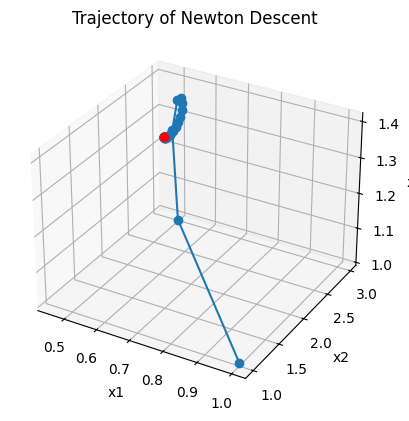

In [39]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

arr_n = np.array(arr_n)

ax.plot(arr_n[:,0], arr_n[:,1], arr_n[:,2], marker="o")
ax.plot(*x_star, marker="o", color="red", label = "CVXPY Solution")

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("Trajectory of Newton Descent")

plt.show()

\newpage

# Problem 3: 

$$ \min_{x \in \mathbb{R}^n} -\sum_{i=1}^n log(1-x_i^2) - \sum_{i=1}^n log(4 + a_i^Tx) $$

In [84]:
# CVX Solution: 

np.random.seed(seed=42)

n = 2000

# generates 2000 random vectors of dim 2000
A = np.random.rand(n, n)

# 2000 variables
x = cp.Variable(n)

# obj func
func = cp.Minimize(-cp.sum(cp.log(1- x**2)) - cp.sum(cp.log(4 + A @ x)) )

problem = cp.Problem(func)

result = problem.solve()

In [85]:
# 3 CVX
cvx_x_star = x.value

if problem.status == cp.OPTIMAL:
    # 1. CVXPY Status
    print(f"Status: {problem.status}")
    
    # 2. Optimal Value f(x*)
    # Note: problem.value reflects the Maximization. 
    # If your original problem was a minimization, use -problem.value
    print(f"Optimal Value f(x*): {problem.value}")
    
    # 3. Norm of x*
    x_norm = np.linalg.norm(x.value)
    print(f"Norm of x* (||x||_2): {x_norm}")

else:
    print(f"Solver was not successful. Status: {problem.status}")

Status: optimal
Optimal Value f(x*): -11919.749025718062
Norm of x* (||x||_2): 25.75919281439763


In [ ]:
# 3 Newton's 
# solution with fixed alpha and beta i randomly chose

np.random.seed(0)

n = 2000

A = np.random.rand(n, n)

alpha = 0.01
beta = 0.5

def f(x):
    term1 = -np.sum(np.log(1 - x**2))
    term2 = -np.sum(np.log(4 + A @ x))
    return term1 + term2

def grad(x) -> np.ndarray:
    #calculate the gradient of the function 
    
    # chain rule for a generic x_i 
    grad_term1 = 2*x / (1-x**2)
    
    # term 2 is - sum (ai / (4 + ai @ x))
    # in general it is - sum (A[i] / (4 + A[i] @ x)) for i in range(n), or -A.T @ (1/ (4 + A @ x))
    grad_term2 = -A.T @ (1/ (4 + A @ x)) 
    
    return grad_term1 + grad_term2

def hess(x) -> np.ndarray:
    # calculate the hessian of the function
    
    # Term 1 
    # since the derivative for x_1 of term 1 is 2*x_1 / (1-x_1**2), it only depends on 1 x  
    # Therefore hessian is a diagonal matrix of the second derivs 
    diag = (2 * (1 + x**2)) / (1 - x**2)**2
    hessian_1 = np.diag(diag)
    
    # Term 2
    # Hessian of term 2 is sum(ai  aiT / (4 + a_i x)^2)
    # This is same as A.T @ diag(1/(4 + A @ x)**2) @ A
    d = 1/(4 + A @ x)**2
    hessian_2 = A.T @ np.diag(d) @ A
    
    return hessian_1 + hessian_2


# compute direction 
def calc_direction(x):
    # delta = - H^-1 * g
    delta = np.linalg.solve(hess(x), -grad(x))
    return delta

# step size 
def step_size(x):
    # backtracking 
    alpha = 0.1
    beta = 0.5
    
    direction = calc_direction(x)
    tol = 1e-50
    while f(x + beta * direction) >= f(x) and beta > tol:
        beta *= alpha
    
    delta = beta * direction
    return delta, beta

x_k = []
x0 = np.zeros(n)
x_k.append(x0)

for i in range(101):
    # compute step size
    curr_x = x_k[-1]
    delta, beta = step_size(curr_x)
    new_x = curr_x + delta
    x_k.append(new_x)
    # print(f"Iter {i}: f={f(curr_x):.4f}, grad_norm={np.linalg.norm(grad(curr_x)):.2e}, t={beta}")

x_star = x_k[-1]
print(f"Newton's Method Solution: {f(x_star)}")

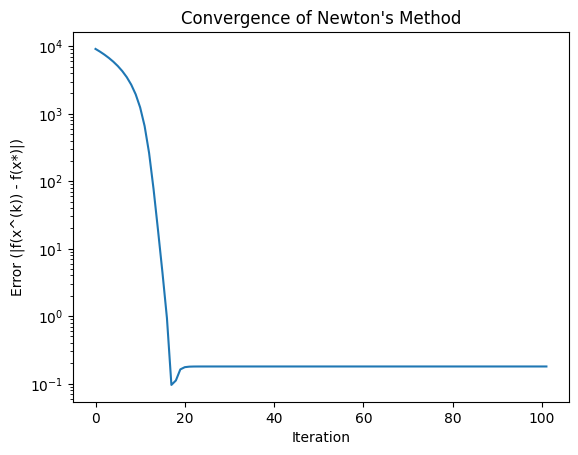

In [93]:
f_vals = np.array([f(x) for x in x_k])

# f_star = problem.value
f_star = f(cvx_x_star)
errors = np.abs(f_vals - f_star)

k = np.arange(len(x_k))

plt.semilogy(k, errors)
plt.xlabel('Iteration')
plt.ylabel('Error (|f(x^(k)) - f(x*)|)')
plt.title('Convergence of Newton\'s Method')
plt.show()

